In [2]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut,TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer,PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
      f1_score,fbeta_score, recall_score, precision_score,
      roc_auc_score, average_precision_score,roc_curve, auc,precision_recall_curve,
      brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
  )
#from sklearn.metrics import fbeta_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show, set_visualize_provider
from interpret.provider import InlineProvider
from sklearn.calibration import calibration_curve
from interpret import show



# Data file imported

In [3]:
data=pd.read_csv("aurora_dataset_clean.csv")

Target: `see_aurora` , features: `featureslow`, we would like to exclude some impossible events which are marked as positive aurora sighting, i.e. during sun way up above the horizon. We dont want to be too restrictive given in the polar regions the (sun elevation angle) `sun_elevation_UTC` may not reach $6^{\degree}$ during certain seasons. Also we are mindful of observers reporting wrong time (i.e. not UTC time but their localtime) and therefore also calculate if sun elevation angle `sun_elevation_localtime` exceeds $6^{\degree}$. If both are yes the sighting was most likely suprious due to light pollution and we turn the `see_aurora` variable False for that observation. However, we dont want to exclude some extreme events like G4 or G5 storms so if $k_{p} \geq 7$ we don't flag it even if the solar brightness conditions were unfavorable for aurora sighting.

In [4]:
day_of_year = pd.to_datetime(data["date"]).dt.dayofyear
declination = np.radians(23.45 * np.sin(np.radians(360/365 * (day_of_year - 81))))
lat_rad = np.radians(data['latitude'])

  # Max elevation = solar noon elevation
data['solar_noon_elev_max'] = np.degrees(
    np.arcsin(
        np.sin(lat_rad) * np.sin(declination) +
        np.cos(lat_rad) * np.cos(declination)
    )
)
polar_winter = data["solar_noon_elev_max"] <= 6
dark_enough = ((data["sun_elevation_localtime"] <= 6) | (data["sun_elevation_utc"] <= 6) | (data["kp"] >= 7))

In [5]:
features0 = ["mlat","mlon","kp","bz_gsm","solar_wind_speed","oval_dist","Ap"]
features1 = ["mlat","mlon","mlt","kp","bz_gsm","sigma_bz_gsm","solar_wind_speed","ap","Ap"]
features2 = ["cloud_cover","visibility","moon_phase","moon_darkness","sun_elevation_utc","sun_elevation_localtime"]
featureslow = ["mlat","mlon","kp","bz_gsm","solar_wind_speed","oval_dist","Ap","cloud_cover","moon_darkness","sun_elevation_utc"]
features1primary0 = ["mlat","mlon","kp","bz_gsm","solar_wind_speed"]
features2primary = ["cloud_cover","moon_darkness","sun_elevation_utc"]
target = "see_aurora"
target2 = "activities_id"




In [6]:
clean_columns=data.columns[~data.isna().any()].tolist()
print(clean_columns)

['raw_row_num', 'obs_id', 'timestamp', 'location', 'see_aurora', 'time_start', 'time_end', 'on_going', 'image', 'latitude', 'longitude', 'redact_row', 'pii_redacted', 'duration', 'utc_dt', 'date', 'hour', 'minute', 'second', 'kp_3hr_bucket', 'kp', 'solar_wind_speed', 'ap', 'Ap', 'cloud_cover', 'visibility', 'moon_phase', 'moon_darkness', 'sun_elevation_utc', 'astronomical_dark_utc', 'sun_elevation_localtime', 'astronomical_dark_localtime', 'solar_noon_elev_max']


In [7]:
dataclean=data.dropna(subset=features1primary0,how='any',inplace=False)

In [8]:
dataclean.groupby("activities_id")["see_aurora"].agg(
      total='count',
      aurora_true=lambda x: (x==1).sum(),
      aurora_false=lambda x: (x==0).sum()
  ).reset_index()

,activities_id,total,aurora_true,aurora_false
0,acti,5281,5281,0
1,quie,7643,7643,0
2,very,1233,1233,0


In [9]:
mymodifiedsighting1 = dataclean[['sun_elevation_utc','sun_elevation_localtime','solar_noon_elev_max',"see_aurora","activities_id"]]
mymodifiedsighting1["see_aurora"] = ((mymodifiedsighting1["see_aurora"] == True) & (polar_winter | dark_enough))
dataclean["see_aurora"]=mymodifiedsighting1["see_aurora"]

An additional attribute in the data is `activities_id`, which predicts how intense the auroral activity was. This could be taken as an alternate target (subjective call, reporting bias) than `see_aurora`. Worth remembering.   

In [10]:
removed_mask = ~(polar_winter | dark_enough)

print(f'Removed positives: {removed_mask.sum()}')
print()
print(pd.cut(
      dataclean.loc[removed_mask, 'mlat'].abs(),
      bins=[0, 45, 55, 62, 75, 90],
      labels=['0-45','45-55','55-62','62-75','75-90']).value_counts().sort_index())

Removed positives: 2306

mlat
0-45      407
45-55    1307
55-62     464
62-75     120
75-90       1
Name: count, dtype: int64


The data from OMNI spaceweather comes prefilled with datapoints which are NaN with suitable string of 9s. This could have an impact on the training if some of these NaNs replaced by these fill values are taken as inputs by the model. We identify and remove them.

In [11]:
fill_values = {
      'solar_wind_speed': 9999.9,
      'bz_gsm':          999.9,
      'sigma_bz_gsm':    999.9,
      'kp':              99,
      'ap':              999,
      'Ap':              999,
  }

for col, fill in fill_values.items():
      if col in dataclean.columns:
          n = (dataclean[col] >= fill * 0.9).sum()  # 90% of fill to catch rounding
          print(f'{col:20s}: {n:>6,} rows with fill value')

mask_valid = (
      (dataclean['solar_wind_speed'] < 9000) &
      (dataclean['bz_gsm'].abs()     < 900)  &
      (dataclean['sigma_bz_gsm']     < 900)  &
      (dataclean['kp']               < 90)   &
      (dataclean['ap']               < 900)  &
      (dataclean['Ap']               < 900)  )

print(f'Rows before: {len(dataclean):,}')
dataclean = dataclean[mask_valid].copy()
print(f'Rows after:  {len(dataclean):,}')
print(f'Dropped:     {(~mask_valid).sum():,}')

solar_wind_speed    :     55 rows with fill value
bz_gsm              :      0 rows with fill value
sigma_bz_gsm        :      0 rows with fill value
kp                  :      0 rows with fill value
ap                  :      0 rows with fill value
Ap                  :      0 rows with fill value
Rows before: 22,186
Rows after:  22,131
Dropped:     55


 Make use of the approximate equatorward auroral oval boundary (Feldstein & Starkov 1967) relation, Positive = observer inside/above oval, negative = outside (aurora unlikely), Here we are using Zhang & Paxton (2008) formula

In [12]:
# (Feldstein & Starkov 1967) # Positive = observer inside/above oval, negative = outside (aurora unlikely)
#dataclean["oval_dist"] = dataclean["mlat"].abs()-(67.5-2.5*dataclean["kp"]) 
mlt_angle = np.pi * (dataclean['mlt'] - 0) / 12
dataclean['oval_dist'] = (
      dataclean['mlat'].abs()
      - (65.2 - 2.4 * dataclean['kp'] + 3.0 * np.cos(mlt_angle)))

In [13]:
dataclean['utc_dt'] = pd.to_datetime(dataclean['utc_dt'],format='ISO8601', utc=True) 
dataclean_timesorted = dataclean.sort_values('utc_dt').reset_index(drop=True)
dataclean_timesorted['mlat_band']= pd.cut(dataclean_timesorted["mlat"].abs(),bins=[0,48,63,90],labels=["00-48","48-63","63-90"])

In [14]:
print(dataclean_timesorted[features1].corr())

                      mlat      mlon       mlt        kp    bz_gsm  \
mlat              1.000000  0.186548  0.035885 -0.072653  0.037273   
mlon              0.186548  1.000000  0.000556  0.100959 -0.094718   
mlt               0.035885  0.000556  1.000000  0.125980 -0.075966   
kp               -0.072653  0.100959  0.125980  1.000000 -0.696567   
bz_gsm            0.037273 -0.094718 -0.075966 -0.696567  1.000000   
sigma_bz_gsm     -0.054728  0.103847  0.102558  0.702101 -0.622455   
solar_wind_speed -0.052541  0.009483  0.033714  0.229740 -0.075948   
ap               -0.099175  0.125556  0.115871  0.887371 -0.788169   
Ap               -0.103652  0.002878  0.096654  0.773415 -0.510055   

                  sigma_bz_gsm  solar_wind_speed        ap        Ap  
mlat                 -0.054728         -0.052541 -0.099175 -0.103652  
mlon                  0.103847          0.009483  0.125556  0.002878  
mlt                   0.102558          0.033714  0.115871  0.096654  
kp             

Break the available data for train and test set keeping the time order. Within the train set split the training data using timeseriessplit for crossvalidation over three `mlat` bands

In [15]:
dataclean_timesorted_alt_train =  dataclean_timesorted[dataclean_timesorted['utc_dt'] <= "2024-07-01"] 
dataclean_timesorted_alt_test =  dataclean_timesorted[dataclean_timesorted['utc_dt'] > "2024-07-01"]

gap = 2 chosen such that same aurora event reported in two consecutive measurements do not spill over folds, maybe not important

In [16]:
tscvtrain=TimeSeriesSplit(n_splits=3, gap=2 )
leavego=LeaveOneGroupOut()

In [17]:
preprocess = ColumnTransformer(transformers=[("sine_mlon",FunctionTransformer(lambda x: np.sin(x)),["mlon"]),
                                                     ("cosine_mlon",FunctionTransformer(lambda x: np.cos(x)),["mlon"])],remainder='passthrough')

In [18]:
feat_names2 = ['sin_mlon', 'cos_mlon'] + [f for f in features0 if f !='mlon'] + [g for g in features2primary]
interactions = [(3,4),(3,5),(4,5)] #[(2,3),(2,4),(3,4)] #(2,3)(3, 4),(3, 5),, 
print("Feature names:", feat_names2)
print("Interactions: ", [(feat_names2[i], feat_names2[j]) for i, j in interactions])

Feature names: ['sin_mlon', 'cos_mlon', 'mlat', 'kp', 'bz_gsm', 'solar_wind_speed', 'oval_dist', 'Ap', 'cloud_cover', 'moon_darkness', 'sun_elevation_utc']
Interactions:  [('kp', 'bz_gsm'), ('kp', 'solar_wind_speed'), ('bz_gsm', 'solar_wind_speed')]


In [19]:
pipeebm2=Pipeline(steps=[('prepro',preprocess),
                        ("EBM",ExplainableBoostingClassifier(feature_names=feat_names2,interactions=interactions,max_bins=128,max_rounds=1000,min_samples_leaf=5,random_state=42))])

In [20]:
# activity_score = {'very': 2.0,   }## confirmed very active, survived darkness filter — boost # 'acti' and 'quie' — no entry, multiplier stays 1.0 (per-band weight unchanged)
def per_band_weights_with_activity(y, bands, activity):
      y_arr    = np.array(y)
      bands_arr = np.array(bands)
      act_arr  = np.array(activity)
      sw       = np.ones(len(y_arr))

      for band in np.unique(bands_arr):
          mask   = bands_arr == band
          y_band = y_arr[mask]
          n_neg  = (y_band == 0).sum()
          n_pos  = (y_band == 1).sum()
          if n_neg == 0 or n_pos == 0:
              continue
          neg_w = len(y_band) / (2 * n_neg)
          pos_w = len(y_band) / (2 * n_pos)
          sw[mask & (y_arr == 0)] = neg_w
          sw[mask & (y_arr == 1)] = pos_w
  
      activity_score = {'very': 2.0}
      for i, (label, pos) in enumerate(zip(act_arr, y_arr)):
          if pos == 1 and label in activity_score:
              sw[i] *= activity_score[label]

      sw = sw / sw.mean()
      return sw


Imbalanced samples, use sample weights for the `mlat` bands, $W_{+}=\frac{N_{tot}}{2\times N_{+}}$ and $W_{-}=\frac{N_{tot}}{2\times N_{-}}$

In [21]:
def per_band_weights(y, bands):
      y     = np.array(y)
      bands = np.array(bands)
      weights = np.ones(len(y), dtype=float)
      for band in np.unique(bands[~pd.isnull(bands)]):
          mask  = bands == band
          y_b   = y[mask]
          n_neg = (y_b == False).sum()
          n_pos = (y_b == True).sum()
          n_tot = len(y_b)
          if n_neg > 0:
              weights[mask & (y == False)] = n_tot / (2 * n_neg)
          if n_pos > 0:
              weights[mask & (y == True)]  = n_tot / (2 * n_pos)
      return weights

In [22]:
fit_results2=[]
for t_fold, (t_train,t_val) in enumerate(tscvtrain.split(dataclean_timesorted_alt_train)):
    tsdata_train= dataclean_timesorted_alt_train.iloc[t_train]
    tsdata_val=dataclean_timesorted_alt_train.iloc[t_val]
    mlat_regions = tsdata_val["mlat_band"].dropna().unique()
    for regions in mlat_regions:
        train_mask = tsdata_train["mlat_band"] != regions
        val_mask = tsdata_val["mlat_band"] == regions
        X_train = tsdata_train.loc[train_mask,featureslow]
        mlat_band_train = tsdata_train.loc[train_mask, 'mlat_band']
        X_val = tsdata_val.loc[val_mask,featureslow]
        y_train = tsdata_train.loc[train_mask,target].astype(int)
        y_val = tsdata_val.loc[val_mask,target].astype(int)



# maybe lower threshold 
        threshold = 0.5
        #sw = per_band_weights(y_train, mlat_band_train)
        sw = per_band_weights_with_activity(y_train, mlat_band_train,tsdata_train.loc[train_mask,target2])
        pipeebm2.fit(X_train,y_train,EBM__sample_weight=sw)
        print("Band counts in this training fold:")
        print(tsdata_train.loc[train_mask, 'mlat_band'].value_counts())
        print()   
        print("Weight stats per band:")
        bands_arr = np.array(tsdata_train.loc[train_mask, 'mlat_band'])
        y_arr     = np.array(y_train)
        for band in np.unique(bands_arr[~pd.isnull(bands_arr)]):
            mask = bands_arr == band
            print(f"  {band}: neg_w={sw[mask & (y_arr==0)][0]:.4f}  pos_w={sw[mask & (y_arr==1)][0]:.4f}  n={mask.sum()}")
      

        
        y_predict_train_prob = pipeebm2.predict_proba(X_train)[:,1]
        y_predict_train= (y_predict_train_prob >= threshold).astype(int) 
        y_predict_val_prob= pipeebm2.predict_proba(X_val)[:,-1]
        y_predict_val= (y_predict_val_prob >= threshold).astype(int) 

        train_scores = {
      'f1'        : f1_score(y_train, y_predict_train),
      'recall'    : recall_score(y_train, y_predict_train),
      'precision' : precision_score(y_train, y_predict_train),
      'roc_auc'   : roc_auc_score(y_train, y_predict_train_prob),
      'pr_auc'    : average_precision_score(y_train, y_predict_train_prob),  
      'brier'     : brier_score_loss(y_train, y_predict_train)}

        val_scores = {
      'f1'        : f1_score(y_val, y_predict_val,zero_division=0),
      'recall'    : recall_score(y_val, y_predict_val,zero_division=0),
      'precision' : precision_score(y_val, y_predict_val,zero_division=0),
      'roc_auc'   : roc_auc_score(y_val, y_predict_val_prob),
      'pr_auc'    : average_precision_score(y_val, y_predict_val_prob),  
      'brier'     : brier_score_loss(y_val, y_predict_val_prob)}
    
        fit_results2.append({
      't_fold':    t_fold,
      'mlat_band': str(regions),          
      'y_val':     list(y_val),      
      'y_pred':    list(y_predict_val),  
      'y_prob':    list(y_predict_val_prob),
      **{f'train_{k}': v for k, v in train_scores.items()},
      **{f'val_{k}':   v for k, v in val_scores.items()},}) 
        fit_results2_df = pd.DataFrame(fit_results2)
        bands = fit_results2_df['mlat_band'].unique()
        print(f'fold={t_fold} band={regions} train={len(X_train)} val={len(X_val)}')

Band counts in this training fold:
mlat_band
63-90    646
00-48    188
48-63      0
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.6371  pos_w=1.8073  n=188
  63-90: neg_w=3.5801  pos_w=0.5424  n=646
fold=0 band=48-63 train=834 val=2630
Band counts in this training fold:
mlat_band
48-63    2624
00-48     188
63-90       0
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.6510  pos_w=1.8468  n=188
  48-63: neg_w=1.5928  pos_w=0.6898  n=2624
fold=0 band=63-90 train=2812 val=535
Band counts in this training fold:
mlat_band
48-63    2624
63-90     646
00-48       0
Name: count, dtype: int64

Weight stats per band:
  48-63: neg_w=1.5879  pos_w=0.6877  n=2624
  63-90: neg_w=3.6470  pos_w=0.5526  n=646
fold=0 band=00-48 train=3270 val=292
Band counts in this training fold:
mlat_band
63-90    1183
00-48     480
48-63       0
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.6304  pos_w=1.8913  n=480
  63-90: neg_w=3.1601  pos_w=0.5560  n=11

In [23]:
ebm_global2 = pipeebm2.named_steps['EBM'].explain_global()
show(ebm_global2)

<!-- http://127.0.0.1:7001/139803990244768/ -->

In [24]:
print(fit_results2_df[['t_fold', 'mlat_band', 'val_f1', 'val_recall','val_precision', 'val_roc_auc']].to_string())

   t_fold mlat_band    val_f1  val_recall  val_precision  val_roc_auc
0       0     48-63  0.714883    0.656822       0.784203     0.715554
1       0     63-90  0.905946    0.945824       0.869295     0.717195
2       0     00-48  0.206186    0.140845       0.384615     0.716525
3       1     48-63  0.812723    0.826548       0.799353     0.651471
4       1     63-90  0.818898    1.000000       0.693333     0.657818
5       1     00-48  0.881668    0.979564       0.801561     0.730460
6       2     48-63  0.656397    0.620550       0.696639     0.584183
7       2     00-48  0.475758    0.465185       0.486822     0.564762
8       2     63-90  0.444444    1.000000       0.285714     0.555556


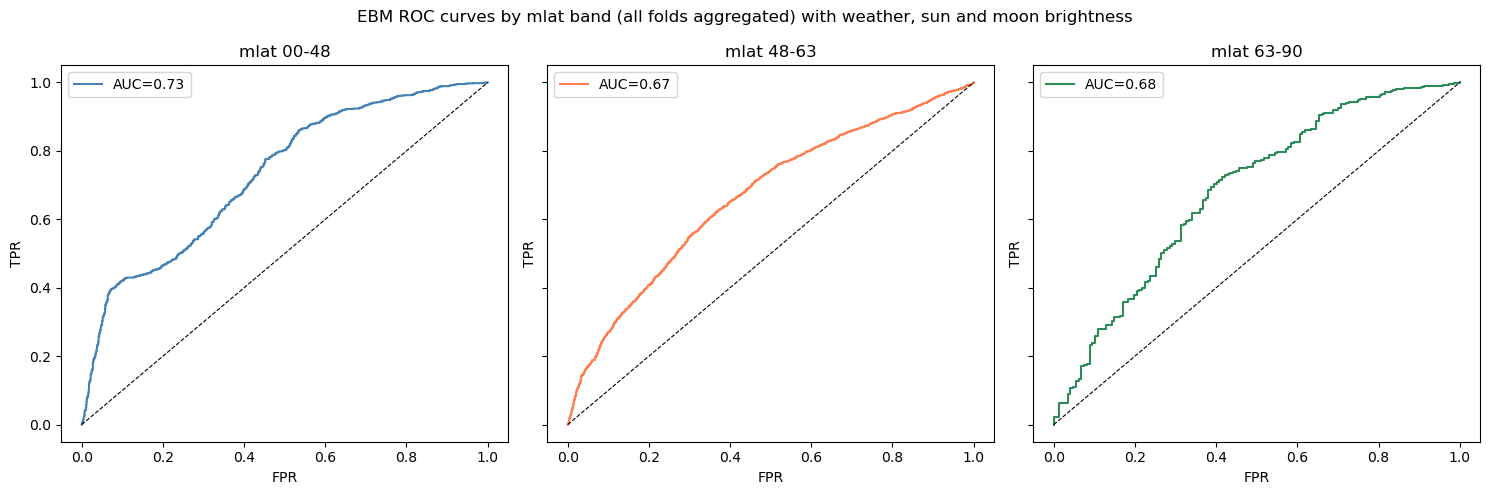

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
bands = sorted(fit_results2_df['mlat_band'].unique())
colors = ['steelblue', 'coral', 'seagreen']

for ax, band, color in zip(axes, bands, colors):
      grp = fit_results2_df[fit_results2_df['mlat_band'] == band]
      y_true_all = sum(grp['y_val'].tolist(), [])
      y_prob_all = sum(grp['y_prob'].tolist(), [])

      fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
      roc_auc = auc(fpr, tpr)
      ax.plot(fpr, tpr, color=color, label=f'AUC={roc_auc:.2f}')
      ax.plot([0,1],[0,1],'k--', linewidth=0.8)
      ax.set(title=f'mlat {band}', xlabel='FPR', ylabel='TPR')
      ax.legend()

plt.suptitle('EBM ROC curves by mlat band (all folds aggregated) with weather, sun and moon brightness')
plt.tight_layout()
plt.show()

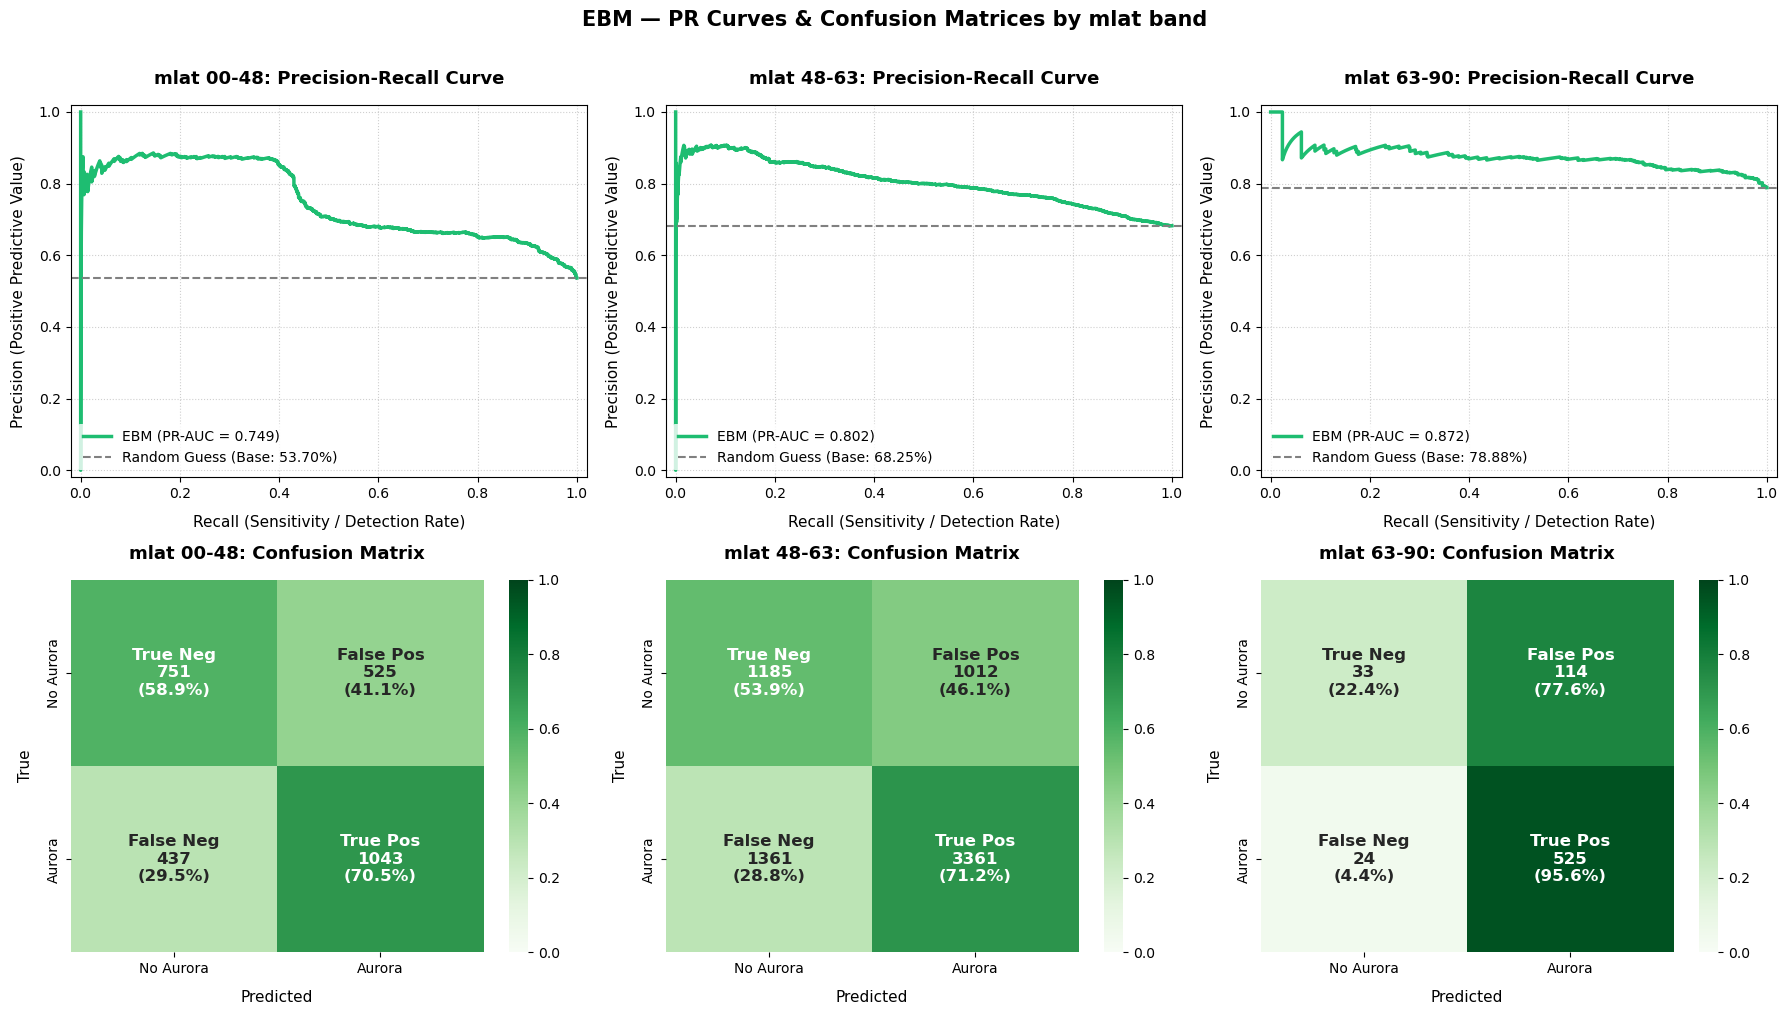

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, band in enumerate(bands):
      grp = fit_results2_df[fit_results2_df['mlat_band'] == band]
      y_true_all = np.array(sum(grp['y_val'].tolist(),  []))
      y_prob_all = np.array(sum(grp['y_prob'].tolist(), []))
      y_pred_all = np.array(sum(grp['y_pred'].tolist(), []))

      # ── PR Curve 
      precisions, recalls, _ = precision_recall_curve(y_true_all, y_prob_all)
      pr_auc = auc(recalls, precisions)
      baseline_ratio = y_true_all.mean()

      ax = axes[0, col]
      ax.plot(recalls, precisions, color='#1ebd71', lw=2.5, label=f'EBM (PR-AUC = {pr_auc:.3f})')
      ax.axhline(y=baseline_ratio, color='gray', lw=1.5, linestyle='--',
  label=f'Random Guess (Base: {baseline_ratio:.2%})')
      ax.set_xlim([-0.02, 1.02])
      ax.set_ylim([-0.02, 1.02])
      ax.set_xlabel('Recall (Sensitivity / Detection Rate)', fontsize=11,
  labelpad=10)
      ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=11,
  labelpad=10)
      ax.set_title(f'mlat {band}: Precision-Recall Curve', fontsize=13,
  weight='bold', pad=15)
      ax.grid(True, linestyle=':', alpha=0.6)
      ax.legend(loc='lower left', frameon=True, facecolor='white',
  edgecolor='none')
  
   
      cm = confusion_matrix(y_true_all, y_pred_all)
      cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
      labels = np.array([
          [f"True Neg\n{cm[0,0]}\n({cm_normalized[0,0]:.1%})", f"False Pos\n{cm[0,1]}\n({cm_normalized[0,1]:.1%})"],
          [f"False Neg\n{cm[1,0]}\n({cm_normalized[1,0]:.1%})", f"True Pos\n{cm[1,1]}\n({cm_normalized[1,1]:.1%})"]
      ])    

      ax = axes[1, col]
      sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Greens",
  cbar=True,
                  xticklabels=['No Aurora', 'Aurora'], yticklabels=['No Aurora', 'Aurora'],
                  vmin=0, vmax=1, ax=ax, annot_kws={"size": 12, "weight":
  "bold"})  
      ax.set_xlabel('Predicted', fontsize=11, labelpad=10)
      ax.set_ylabel('True', fontsize=11, labelpad=10)
      ax.set_title(f'mlat {band}: Confusion Matrix', fontsize=13,
  weight='bold', pad=15)

plt.suptitle('EBM — PR Curves & Confusion Matrices by mlat band',
  fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

Training on the full training set, data upto July 1st 2024

Band counts in full training set:
mlat_band
48-63    9543
00-48    2944
63-90    1344
Name: count, dtype: int64

Weight stats per band:
  00-48: neg_w=0.9999  pos_w=0.9253  n=2944
  48-63: neg_w=1.5338  pos_w=0.6999  n=9543
  63-90: neg_w=2.7840  pos_w=0.5808  n=1344

=== Per-band Train Set Scores ===

=== 00-48 (n=2944) ===
  F1=0.754  Recall=0.700  Precision=0.817
  ROC-AUC=0.846  PR-AUC=0.855  Brier=0.159

=== 48-63 (n=9543) ===
  F1=0.823  Recall=0.785  Precision=0.864
  ROC-AUC=0.839  PR-AUC=0.914  Brier=0.159

=== 63-90 (n=1344) ===
  F1=0.852  Recall=0.801  Precision=0.910
  ROC-AUC=0.798  PR-AUC=0.944  Brier=0.177
{'f1': 0.8151419558359622, 'recall': 0.7728953665433979, 'precision': 0.8622739958742871, 'roc_auc': 0.8409910491455619, 'pr_auc': 0.9040779322532854, 'brier': 0.2330272576097173}


<!-- http://127.0.0.1:7001/139804018666640/ -->

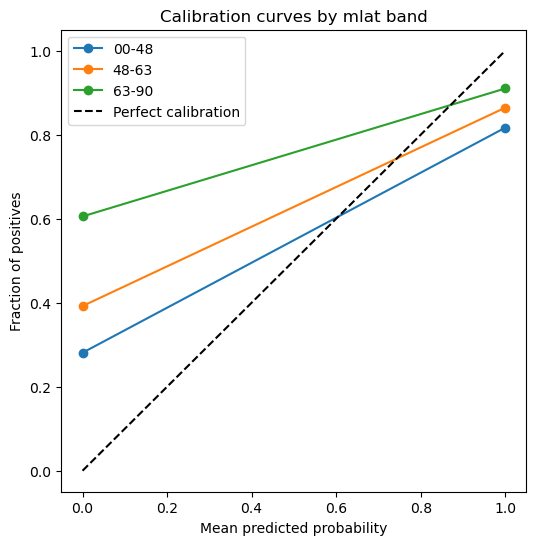

In [27]:
sw_full = per_band_weights_with_activity(
      dataclean_timesorted_alt_train[target].astype(int),
      dataclean_timesorted_alt_train['mlat_band'],dataclean_timesorted_alt_train['activities_id']
  )
  
  # Sanity check weights
print("Band counts in full training set:")
print(dataclean_timesorted_alt_train['mlat_band'].value_counts())
print()
print("Weight stats per band:")
bands_arr = np.array(dataclean_timesorted_alt_train['mlat_band'])
y_arr     = np.array(dataclean_timesorted_alt_train[target].astype(int))
for band in np.unique(bands_arr[~pd.isnull(bands_arr)]):
      mask = bands_arr == band
      neg_w = sw_full[mask & (y_arr == 0)]
      pos_w = sw_full[mask & (y_arr == 1)]
      neg_str = f"{neg_w[0]:.4f}" if len(neg_w) > 0 else "N/A"
      pos_str = f"{pos_w[0]:.4f}" if len(pos_w) > 0 else "N/A"
      print(f"  {band}: neg_w={neg_str}  pos_w={pos_str}  n={mask.sum()}")


# Fit on full training set
X_train_full = dataclean_timesorted_alt_train[featureslow]
y_train_full = dataclean_timesorted_alt_train[target].astype(int)

pipeebm2.fit(X_train_full, y_train_full, EBM__sample_weight=sw_full)

# Training set predictions
y_predict_fulltrain_prob = pipeebm2.predict_proba(X_train_full)[:, 1]
y_predict_fulltrain      = (y_predict_fulltrain_prob >= 0.5).astype(int)

mlat_train_full = dataclean_timesorted_alt_train['mlat_band']
bands = sorted(dataclean_timesorted_alt_train['mlat_band'].dropna().unique())

print("\n=== Per-band Train Set Scores ===")
for band in bands:
      mask = (mlat_train_full == band).values
      if mask.sum() < 10:
            continue

      y_band    = y_train_full[mask]
      y_prob    = y_predict_fulltrain_prob[mask]
      y_pred    = y_predict_fulltrain[mask]

      print(f'\n=== {band} (n={mask.sum()}) ===')
      print(f'  F1={f1_score(y_band, y_pred):.3f}  '
            f'Recall={recall_score(y_band, y_pred):.3f}  '
            f'Precision={precision_score(y_band, y_pred):.3f}')
      print(f'  ROC-AUC={roc_auc_score(y_band, y_prob):.3f}  '
            f'PR-AUC={average_precision_score(y_band, y_prob):.3f}  '
            f'Brier={brier_score_loss(y_band, y_prob):.3f}')

        

train_scores_full = {
'f1'        : f1_score(y_train_full, y_predict_fulltrain),
'recall'    : recall_score(y_train_full, y_predict_fulltrain),
'precision' : precision_score(y_train_full, y_predict_fulltrain),
'roc_auc'   : roc_auc_score(y_train_full, y_predict_fulltrain_prob),
'pr_auc'    : average_precision_score(y_train_full, y_predict_fulltrain_prob),  
'brier'     : brier_score_loss(y_train_full, y_predict_fulltrain)}
print(train_scores_full)
ebm_global_full = pipeebm2.named_steps['EBM'].explain_global()
show(ebm_global_full)
fig, ax = plt.subplots(figsize=(6, 6))
for band in bands:
    mask = (mlat_train_full == band).values
    if mask.sum() < 10:
        continue
    frac_pos, mean_pred = calibration_curve(
        y_train_full[mask], y_predict_fulltrain[mask], n_bins=10
    )
    ax.plot(mean_pred, frac_pos, marker='o', label=band)

ax.plot([0,1],[0,1], 'k--', label='Perfect calibration')
ax.set(xlabel='Mean predicted probability', ylabel='Fraction of positives',
        title='Calibration curves by mlat band')
ax.legend()
plt.show()

Working on held out test data from 01st July 2024 to 31st July 2025

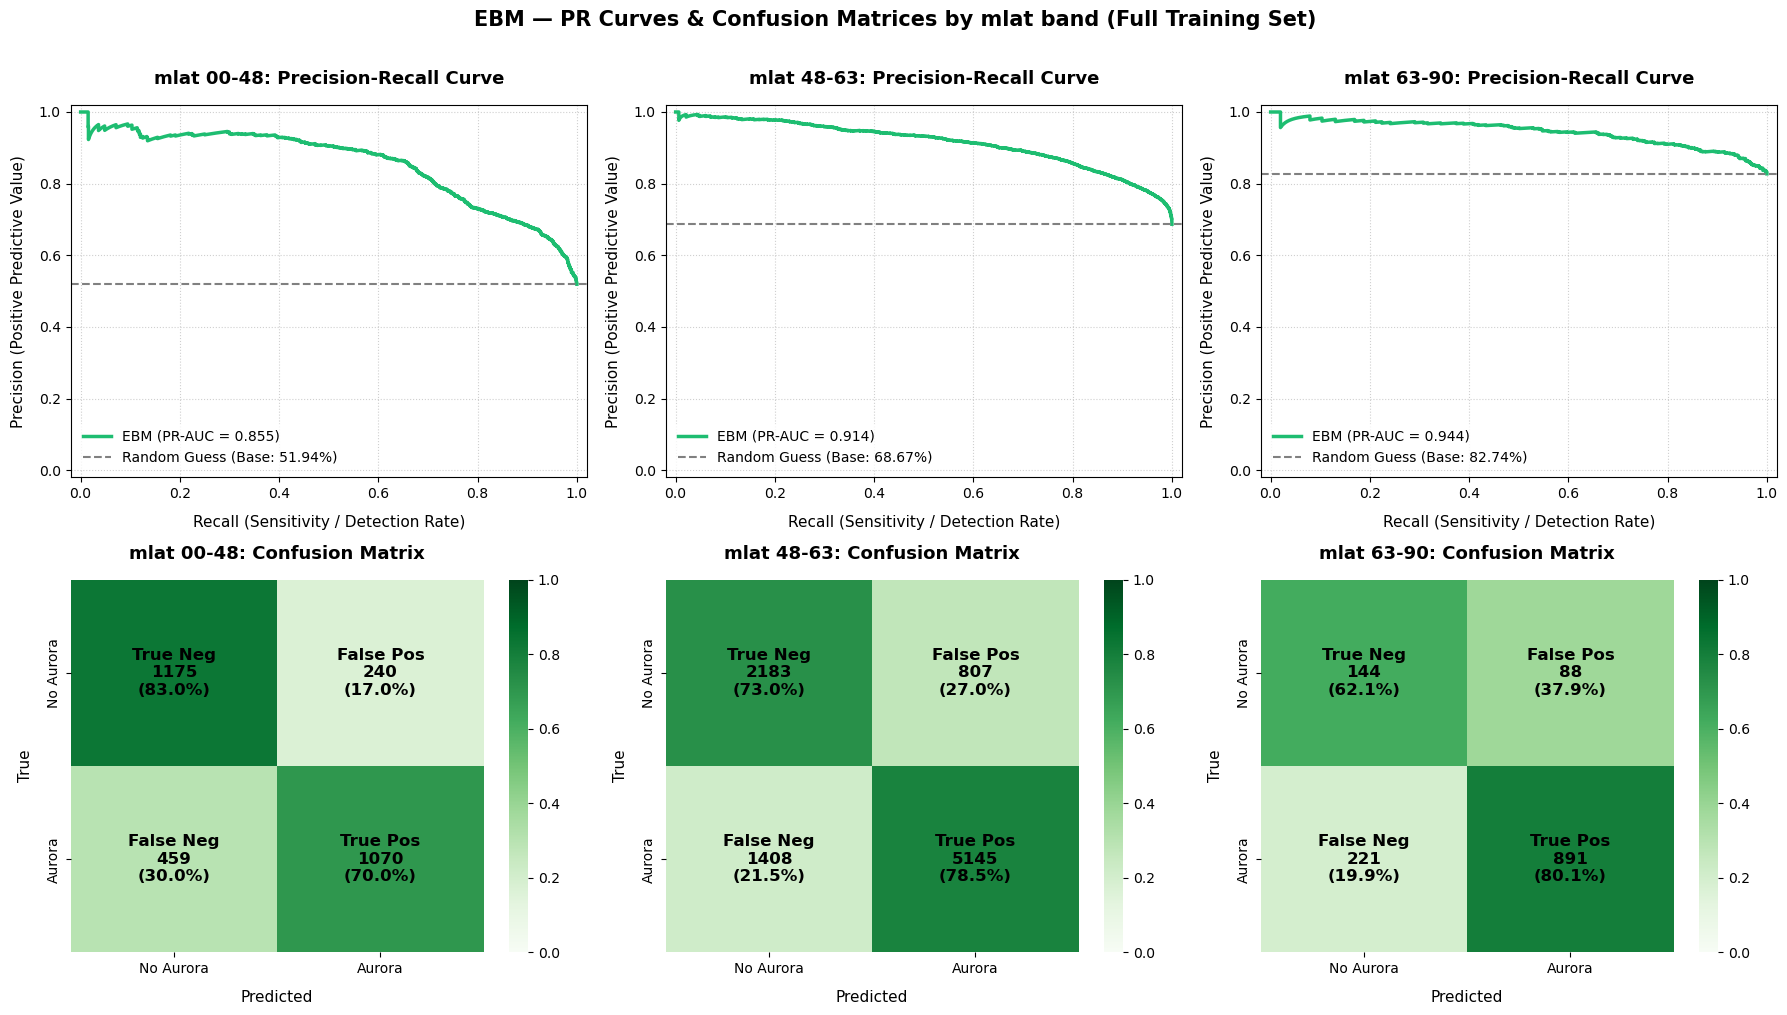

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

y_prob_train = pipeebm2.predict_proba(X_train_full[featureslow])[:, 1]
y_pred_train = (y_prob_train >= 0.5).astype(int)
y_true_train = np.array(y_train_full)
bands_train  = np.array(mlat_train_full)

for col, band in enumerate(bands):
    mask       = bands_train == band
    y_true_all = y_true_train[mask]
    y_prob_all = y_prob_train[mask]
    y_pred_all = y_pred_train[mask]

    # ── PR Curve
    precisions, recalls, _ = precision_recall_curve(y_true_all, y_prob_all)
    pr_auc         = average_precision_score(y_true_all, y_prob_all)
    baseline_ratio = y_true_all.mean()

    ax = axes[0, col]
    ax.plot(recalls, precisions, color='#1ebd71', lw=2.5, label=f'EBM (PR-AUC = {pr_auc:.3f})')
    ax.axhline(y=baseline_ratio, color='gray', lw=1.5, linestyle='--',
            label=f'Random Guess (Base: {baseline_ratio:.2%})')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('Recall (Sensitivity / Detection Rate)', fontsize=11,
    labelpad=10)
    ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=11,
    labelpad=10)
    ax.set_title(f'mlat {band}: Precision-Recall Curve', fontsize=13,
    weight='bold', pad=15)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower left', frameon=True, facecolor='white',
    edgecolor='none')

# ── Confusion Matrix
    cm            = confusion_matrix(y_true_all, y_pred_all)
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels        = np.array([
    [f"True Neg\n{cm[0,0]}\n({cm_normalized[0,0]:.1%})", f"False Pos\n{cm[0,1]}\n({cm_normalized[0,1]:.1%})"],
    [f"False Neg\n{cm[1,0]}\n({cm_normalized[1,0]:.1%})", f"True Pos\n{cm[1,1]}\n({cm_normalized[1,1]:.1%})"]
    ])    

    ax = axes[1, col]
    sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Greens",
    cbar=True,
            xticklabels=['No Aurora', 'Aurora'], yticklabels=['No Aurora', 'Aurora'],
            vmin=0, vmax=1, ax=ax, annot_kws={"size": 12, "weight":
    "bold", "color": "black"})
    ax.set_xlabel('Predicted', fontsize=11, labelpad=10)
    ax.set_ylabel('True', fontsize=11, labelpad=10)
    ax.set_title(f'mlat {band}: Confusion Matrix', fontsize=13,
    weight='bold', pad=15)

plt.suptitle('EBM — PR Curves & Confusion Matrices by mlat band (Full Training Set)',fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [29]:
X_test_full      = dataclean_timesorted_alt_test[featureslow]
y_test_full      = dataclean_timesorted_alt_test[target].astype(int)
mlat_test        = dataclean_timesorted_alt_test['mlat_band']

y_predict_test_prob = pipeebm2.predict_proba(X_test_full)[:, 1]
y_predict_test      = (y_predict_test_prob >= 0.5).astype(int)

print('=== Per-band Test Set Scores ===\n')

for band in mlat_regions:
    mask   = (mlat_test == band).values
    if mask.sum() == 0:
        continue
    y_band     = y_test_full.values[mask]
    prob_band  = y_predict_test_prob[mask]
    pred_band  = y_predict_test[mask]

    f1  = f1_score(y_band, pred_band, zero_division=0)
    rec = recall_score(y_band, pred_band, zero_division=0)
    pre = precision_score(y_band, pred_band, zero_division=0)
    auc = roc_auc_score(y_band, prob_band)
    pr  = average_precision_score(y_band, prob_band)
    bri = brier_score_loss(y_band, prob_band)

    print(f'=== {band} (n={mask.sum()}) ===')
    print(f'  F1={f1:.3f}  Recall={rec:.3f}  Precision={pre:.3f}')
    print(f'  ROC-AUC={auc:.3f}  PR-AUC={pr:.3f}  Brier={bri:.3f}\n')

=== Per-band Test Set Scores ===

=== 48-63 (n=6312) ===
  F1=0.594  Recall=0.483  Precision=0.771
  ROC-AUC=0.643  PR-AUC=0.780  Brier=0.262

=== 00-48 (n=1743) ===
  F1=0.648  Recall=0.566  Precision=0.758
  ROC-AUC=0.693  PR-AUC=0.777  Brier=0.236

=== 63-90 (n=245) ===
  F1=0.843  Recall=0.814  Precision=0.873
  ROC-AUC=0.743  PR-AUC=0.915  Brier=0.188



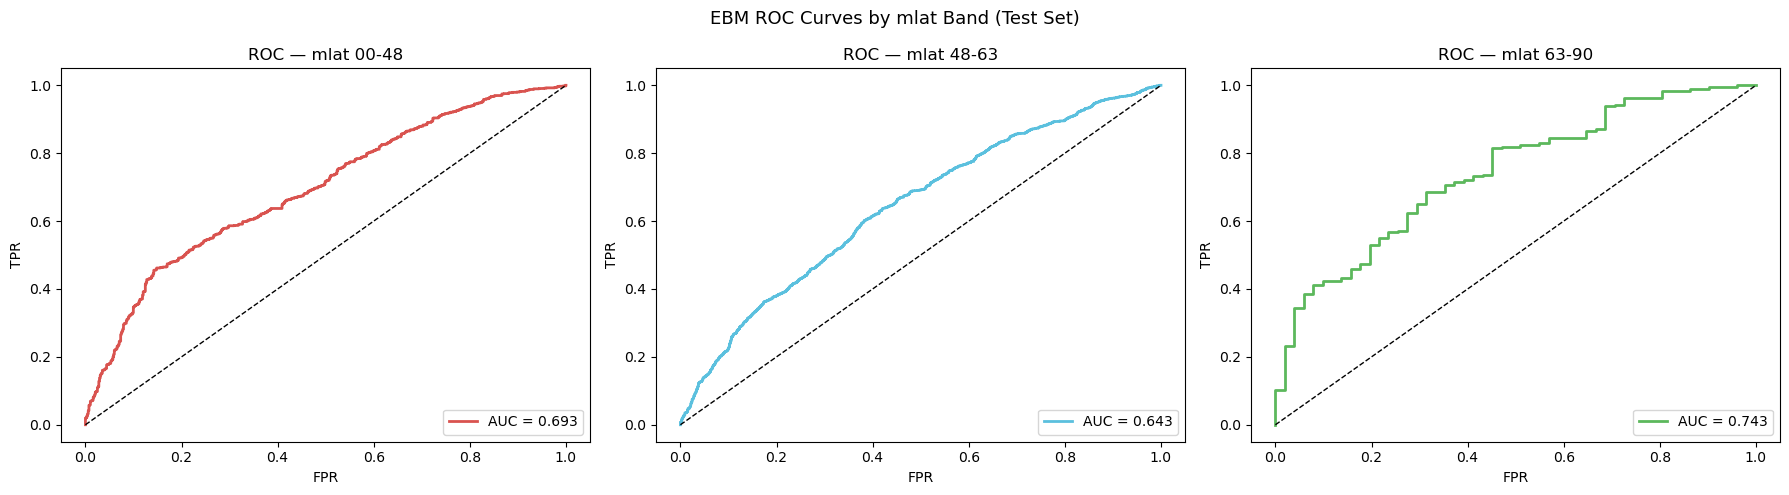

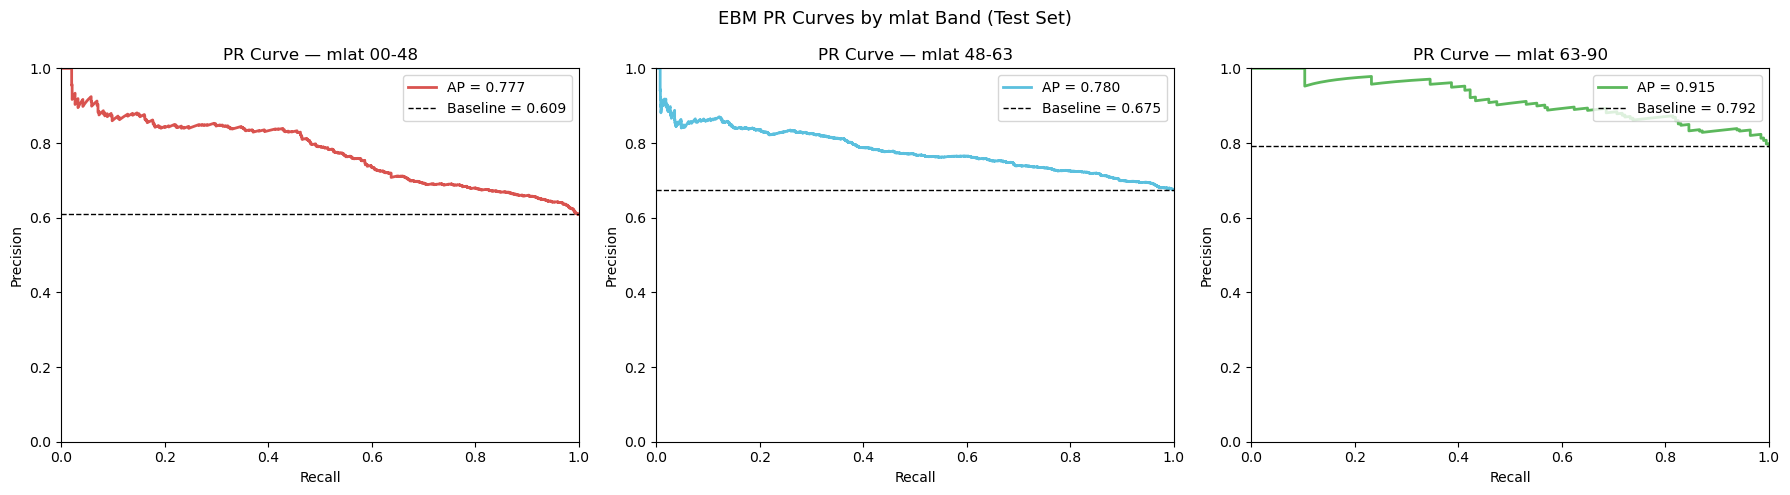

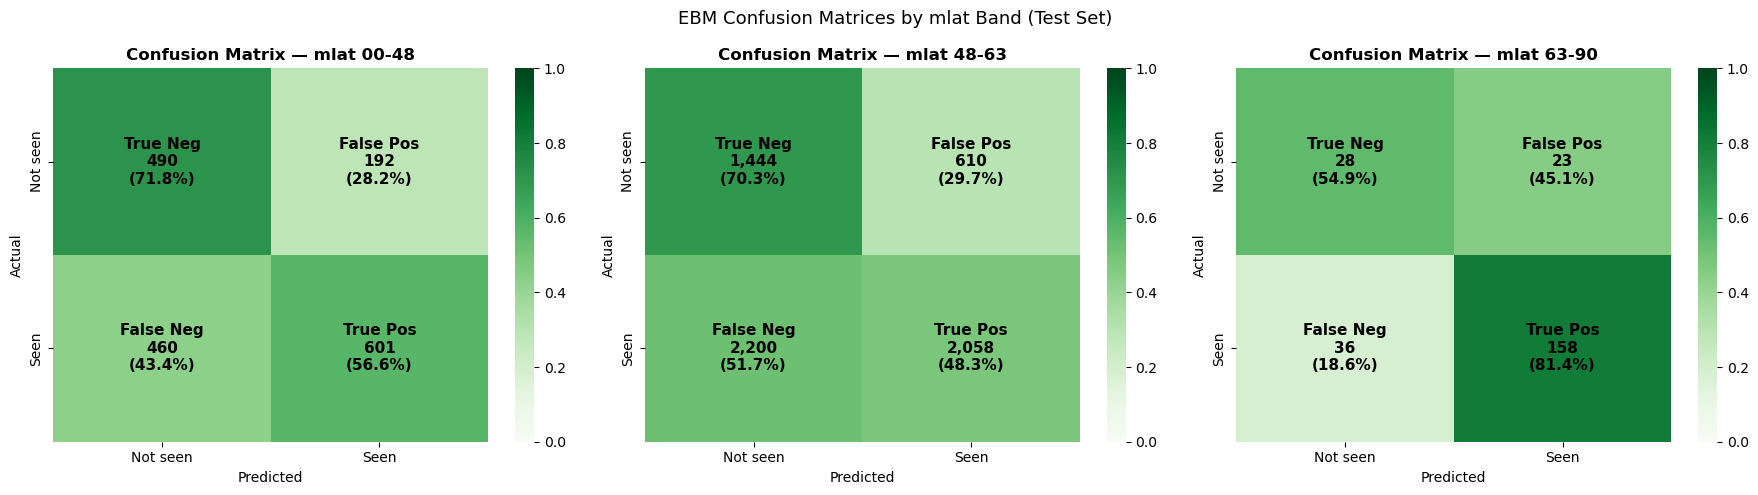

<Figure size 640x480 with 0 Axes>

In [30]:
 # ── Test set predictions 
X_test_full      = dataclean_timesorted_alt_test[featureslow]
y_test_full      = dataclean_timesorted_alt_test[target].astype(int)
mlat_test        = dataclean_timesorted_alt_test['mlat_band']

y_predict_test_prob = pipeebm2.predict_proba(X_test_full)[:, 1]
y_predict_test      = (y_predict_test_prob >= 0.5).astype(int)


bands  = sorted(dataclean_timesorted_alt_test['mlat_band'].dropna().unique())
colors = {'00-48': '#d9534f', '48-63': '#5bc0de', '63-90': '#5cb85c'}

# ── ROC Curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, band in zip(axes, bands):
    mask = (mlat_test == band).values
    if mask.sum() < 10:
        ax.text(0.5, 0.5, f'Insufficient data\n(n={mask.sum()})',
                ha='center', va='center', transform=ax.transAxes)
        ax.set(title=f'ROC — mlat {band}')
        continue
    fpr, tpr, _ = roc_curve(y_test_full.values[mask],y_predict_test_prob[mask])
    roc_auc     = roc_auc_score(y_test_full[mask], y_predict_test_prob[mask])
    ax.plot(fpr, tpr, color=colors[band], lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0,1], [0,1], 'k--', lw=1)
    ax.set(title=f'ROC — mlat {band}', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
plt.suptitle('EBM ROC Curves by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()
# ── PR Curves 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, band in zip(axes, bands):
    mask = (mlat_test == band).values
    if mask.sum() < 10:
        continue
    precision, recall, _ = precision_recall_curve(y_test_full[mask],y_predict_test_prob[mask])
    ap       = average_precision_score(y_test_full[mask],y_predict_test_prob[mask])
    baseline = y_test_full[mask].mean()
    ax.plot(recall, precision, color=colors[band], lw=2, label=f'AP = {ap:.3f}')
    ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline = {baseline:.3f}')
    ax.set(title=f'PR Curve — mlat {band}', xlabel='Recall',ylabel='Precision',xlim=[0,1], ylim=[0,1])
    ax.legend(loc='upper right')
plt.suptitle('EBM PR Curves by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


for ax, band in zip(axes, bands):
    mask = (mlat_test == band).values
    if mask.sum() < 10:
        continue
    cm = confusion_matrix(y_test_full[mask], y_predict_test[mask])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    labels = np.array([
        [f"True Neg\n{cm[0,0]:,}\n({cm_normalized[0,0]:.1%})",
        f"False Pos\n{cm[0,1]:,}\n({cm_normalized[0,1]:.1%})"],
        [f"False Neg\n{cm[1,0]:,}\n({cm_normalized[1,0]:.1%})",
        f"True Pos\n{cm[1,1]:,}\n({cm_normalized[1,1]:.1%})"]
    ])    

    sns.heatmap(cm_normalized, annot=labels, fmt='', cmap='Greens',
                vmin=0, vmax=1, ax=ax, cbar=True,
                xticklabels=['Not seen', 'Seen'],
                yticklabels=['Not seen', 'Seen'],
                annot_kws={'size': 11, 'weight': 'bold', 'color': 'black'})

    ax.set_title(f'Confusion Matrix — mlat {band}', fontsize=12,
weight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('EBM Confusion Matrices by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()


plt.suptitle('EBM Confusion Matrices by mlat Band (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [31]:
wrong = dataclean_timesorted_alt_train.copy()
wrong['prob'] = y_predict_fulltrain_prob
wrong['pred'] = y_predict_fulltrain

false_negatives = wrong[(wrong[target]==True)  & (wrong['pred']==0)]
false_positives = wrong[(wrong[target]==False) & (wrong['pred']==1)]

print(false_negatives[['mlat','kp','bz_gsm','cloud_cover','solar_wind_speed']]
.describe())
print(false_positives[['mlat','kp','bz_gsm','cloud_cover','solar_wind_speed']]
.describe())

              mlat           kp       bz_gsm  cloud_cover  solar_wind_speed
count  2088.000000  2088.000000  2088.000000  2088.000000       2088.000000
mean     50.907297     3.127011     0.193383    50.152299        594.024585
std      12.866669     2.263180     3.624701    42.398081        578.707269
min     -52.788243     0.000000   -16.566667     0.000000        280.000000
25%      48.385101     1.300000    -1.766667     3.000000        383.083333
50%      52.167098     2.700000     0.100000    46.500000        463.833333
75%      56.043491     4.300000     2.366667    99.000000        637.000000
max      83.213953     8.700000    21.566667   100.000000       6907.000000
              mlat           kp       bz_gsm  cloud_cover  solar_wind_speed
count  1135.000000  1135.000000  1135.000000  1135.000000       1135.000000
mean     51.623670     5.115771    -4.677210    44.474009        614.439941
std      17.090182     2.626538     7.903042    41.655797        338.509876
min     -81.

(array([195., 339., 367., 435., 425., 468., 488., 521., 532., 522., 535.,
        567., 523., 557., 599., 618., 637., 725., 723., 751., 822., 946.,
        674., 534., 328.]),
 array([0.01799049, 0.05694542, 0.09590036, 0.13485529, 0.17381023,
        0.21276516, 0.2517201 , 0.29067503, 0.32962997, 0.3685849 ,
        0.40753983, 0.44649477, 0.4854497 , 0.52440464, 0.56335957,
        0.60231451, 0.64126944, 0.68022437, 0.71917931, 0.75813424,
        0.79708918, 0.83604411, 0.87499905, 0.91395398, 0.95290892,
        0.99186385]),
 <BarContainer object of 25 artists>)

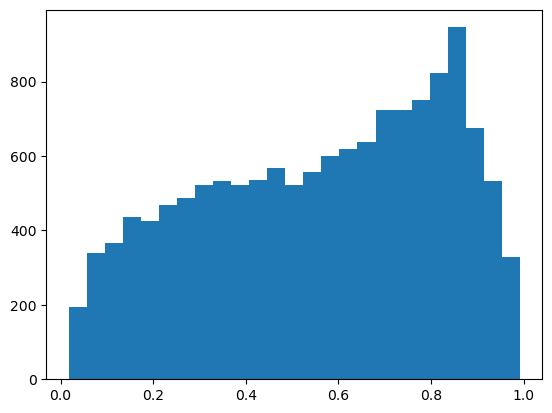

In [32]:
plt.hist(y_predict_fulltrain_prob, bins=25)

In [33]:
y_test_arr   = dataclean_timesorted_alt_test["see_aurora"]
probs_test   = pipeebm2.predict_proba(dataclean_timesorted_alt_test[featureslow])[:, 1]
preds_test   = (probs_test >= 0.3).astype(int)

fn_mask = (y_test_arr == 1) & (preds_test == 0)
fn_idx  = np.where(fn_mask)[0]
print(f'False negatives: {fn_mask.sum()}')
print(dataclean_timesorted_alt_test[featureslow].iloc[fn_idx[:5]][['mlat', 'kp', 'bz_gsm', 'oval_dist',
'sun_elevation_utc']])

# Pick first false negative and explain
sample_idx = fn_idx[0]
X_fn = dataclean_timesorted_alt_test[featureslow].iloc[[sample_idx]]
y_fn = dataclean_timesorted_alt_test["see_aurora"].iloc[[sample_idx]]

X_fn_transformed = pipeebm2[:-1].transform(X_fn)

ebm = pipeebm2.named_steps['EBM']
show(ebm.explain_local(X_fn_transformed, y_fn.values), 0)

False negatives: 977
            mlat   kp    bz_gsm  oval_dist  sun_elevation_utc
13834  54.232426  1.3 -1.333333 -10.125982         -14.122293
13848  47.588970  1.0  1.366667 -17.058736           2.809571
13849  47.598849  1.0  1.366667 -17.048606           1.231615
13850  47.605425  0.7  1.500000 -17.763407           0.705059
13851  47.606452  0.7  1.500000 -17.761899           0.383715


<!-- http://127.0.0.1:7001/139802384710832/ -->

In [34]:
y_test_arr   = dataclean_timesorted_alt_test["see_aurora"]
probs_test   = pipeebm2.predict_proba(dataclean_timesorted_alt_test[featureslow])[:, 1]
preds_test   = (probs_test >= 0.3).astype(int)

fn_mask = (y_test_arr == 0) & (preds_test == 1)
fn_idx  = np.where(fn_mask)[0]
print(f'False positive: {fn_mask.sum()}')
print(dataclean_timesorted_alt_test[featureslow].iloc[fn_idx[:5]][['mlat', 'kp', 'bz_gsm', 'oval_dist',
'sun_elevation_utc']])

# Pick first false negative and explain
sample_idx = fn_idx[0]
X_fn = dataclean_timesorted_alt_test[featureslow].iloc[[sample_idx]]
y_fn = dataclean_timesorted_alt_test["see_aurora"].iloc[[sample_idx]]

X_fn_transformed = pipeebm2[:-1].transform(X_fn)

ebm = pipeebm2.named_steps['EBM']
show(ebm.explain_local(X_fn_transformed, y_fn.values), 0)

False positive: 1792
            mlat   kp        bz_gsm  oval_dist  sun_elevation_utc
13832  59.998384  0.3 -3.000000e-01  -7.017651           1.409012
13838  59.991687  2.0 -1.666667e+00  -1.539551           8.424664
13840  56.463854  2.0 -1.666667e+00  -6.554461         -16.110179
13841  57.137956  3.0  1.480297e-16  -3.683444          48.930445
13844 -48.016864  2.7  3.333333e-01  -9.148193           1.095843


<!-- http://127.0.0.1:7001/139803956314080/ -->

# Predictions based on limited July 4th, 2026 geomagnetic indices data

Max prob    : 0.9658
Mean prob   : 0.8017
probs >= 0.3: 11041
probs >= 0.5: 11041
probs >= 0.7: 8643


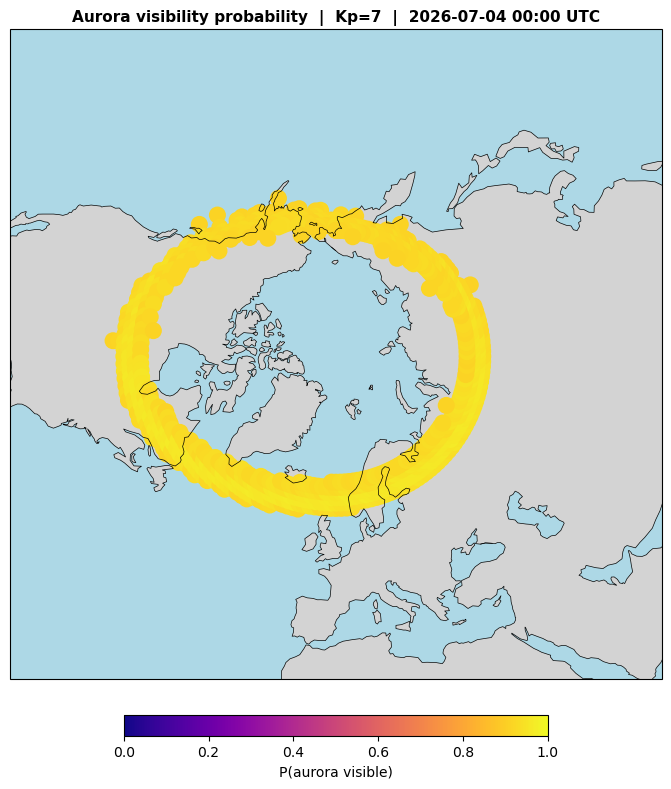

In [38]:
import aacgmv2
import datetime                                       
import cartopy.crs as ccrs
import cartopy.feature as cfeature
KP_TO_AP = {0:0, 1:3, 2:7, 3:15, 4:27, 5:48, 6:80, 7:140, 8:240, 9:400}

kp_input = 7
dt       = datetime.datetime(2026, 7, 4, 0, 0, 0)

# ── Geographic grid 
geo_lats = np.arange(30, 91, 1, dtype=float)
geo_lons = np.arange(-180, 181, 2, dtype=float)
geo_lon_mesh, geo_lat_mesh = np.meshgrid(geo_lons, geo_lats)

geo_lat_flat = geo_lat_mesh.flatten()
geo_lon_flat = geo_lon_mesh.flatten()

# ── AACGM conversion: geographic → mlat, mlon, mlt 
mlat_flat, mlon_flat, mlt_flat = aacgmv2.get_aacgm_coord_arr(
    geo_lat_flat, geo_lon_flat,
    np.zeros_like(geo_lat_flat), 
    dt
)

# ── oval_dist — Zhang & Paxton MLT-aware formula 
mlt_angle      = np.pi * mlt_flat / 12
oval_dist_flat = mlat_flat - (65.2 - 2.4 * kp_input + 3.0 *
np.cos(mlt_angle))

# ── Build prediction DataFrame 
sweep_df = pd.DataFrame({
    'mlat':              mlat_flat,
    'mlon':              mlon_flat,
    'kp':                float(kp_input),
    'bz_gsm':           -5.0,
    'sigma_bz_gsm':      4.0,
    'solar_wind_speed':  650.0,
    'Ap':                float(KP_TO_AP.get(kp_input, 27)),
    'oval_dist':         oval_dist_flat,
    'cloud_cover':       0.0,
    'sun_elevation_utc': -30.0,
    'moon_darkness':     1.0,
})

# Drop rows where AACGM returned NaN
valid = sweep_df.notna().all(axis=1)
probs = np.full(len(sweep_df), np.nan)
probs[valid] = pipeebm2.predict_proba(sweep_df.loc[valid, featureslow])[:,
1]

print(f'Max prob    : {np.nanmax(probs):.4f}')
print(f'Mean prob   : {np.nanmean(probs):.4f}')
print(f'probs >= 0.3: {(probs >= 0.3).sum()}')
print(f'probs >= 0.5: {(probs >= 0.5).sum()}')
print(f'probs >= 0.7: {(probs >= 0.7).sum()}')

# ── Plot 
threshold = 0.91
mask = (probs >= threshold) & ~np.isnan(probs)

fig, ax = plt.subplots(1, 1, figsize=(8, 8),
                        subplot_kw={'projection': ccrs.NorthPolarStereo()})

ax.add_feature(cfeature.LAND,      facecolor='lightgray')
ax.add_feature(cfeature.OCEAN,     facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent([-180, 180, 30, 90], crs=ccrs.PlateCarree())

if mask.sum() > 0:  
    sc = ax.scatter(
      geo_lon_flat[mask], geo_lat_flat[mask],
      c=probs[mask], cmap='plasma', vmin=0, vmax=1,
      s=150, marker='o', linewidths=0,
      transform=ccrs.PlateCarree()
  )

    plt.colorbar(sc, ax=ax, orientation='horizontal',
                fraction=0.03, pad=0.05, label='P(aurora visible)')
else:
    ax.text(0.5, 0.5, 'No points above threshold',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

ax.set_title(f'Aurora visibility probability  |  Kp={kp_input}  |  '
            f'{dt.strftime("%Y-%m-%d %H:%M UTC")}',
            fontsize=11, weight='bold')

plt.tight_layout()
plt.show()